# File to run experiments with various hyperparameters

In [1]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os
import csv
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from strats.data_labeling import build_aki_outcome, build_cf_outcome

print(datetime.datetime.now())

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TORCH_USE_CUDA_DSA"] = '1'

np.random.seed(9871)
torch.manual_seed(9871)

Initializing package . . . 😘
2025-05-15 16:12:53.556648


# Prepare Data

In [2]:

def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct,
            'lower_1' : vals.quantile(0.01),
            'upper_1' : vals.quantile(0.99),
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats


def mask_rows_by_proportion(df: pd.DataFrame, mask_ratio: float, seed: int = 42) -> pd.DataFrame:
    """
    주어진 DataFrame (컬럼: ['offset', 'hadm_id', 'itemid', 'value'])에 대해,
    각 hadm_id별로 전체 관측치 중 일정 비율(mask_ratio)을 무작위로 masking 처리합니다.
    (mask_ratio 예: 0.3이면 각 hadm_id 그룹의 30% 행의 value를 NaN으로 설정)
    
    Parameters:
      df: DataFrame with columns ['offset', 'hadm_id', 'itemid', 'value']
      mask_ratio: masking할 비율 (예: 0.3)
      seed: 재현성을 위한 난수 시드
      
    Returns:
      df_masked: 원본 DataFrame과 동일한 구조이며, 각 hadm_id별로 mask_ratio에 해당하는 행의 'value'가 NaN 처리됨.
    """
    df_masked = df.copy()
    np.random.seed(seed)
    
    # 각 hadm_id 그룹별로 처리
    for hadm_id, group in df_masked.groupby('hadm_id'):
        idxs = group.index
        n_rows = len(idxs)
        n_to_mask = int(np.floor(n_rows * mask_ratio))
        if n_to_mask > 0:
            mask_idxs = np.random.choice(idxs, size=n_to_mask, replace=False)
            df_masked.loc[mask_idxs, 'value'] = np.nan
            
    return df_masked

### All vars

In [3]:
data_static = pd.read_feather('eicu_data_static.feather').rename(columns={'patientunitstayid' : 'hadm_id'})

def process_eicu_static(static):
    # Treat only in-hospital death
    static.loc[static['unitdischargestatus'] == 'Alive', 'unitdischargeoffset'] = None
    static = static.loc[:,['hadm_id', 'unitdischargeoffset']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'unitdischargeoffset' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

eicu_outcome, eicu_ids = process_eicu_static(data_static)
data_eicu_vital = pd.read_feather('eicu_data_vital.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()
data_eicu_lab = pd.read_feather('eicu_data_lab.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()
data_eicu_treatment = pd.read_feather('eicu_data_treatment.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()
data_eicu_treatment_new = pd.read_feather('eicu_data_treatment_new.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates() # to label CF
data_eicu_treatment_new = data_eicu_treatment_new.loc[data_eicu_treatment_new['itemid']=='c01', :]


mimic_static = pd.read_feather('mimic_data_static.feather')

def process_mimic_static(static):
    # Treat in-unit death
    static.loc[static['mortality_inunit']==0, 'outtime'] = None
    static = static.loc[:,['hadm_id', 'outtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'outtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

mimic_outcome, mimic_ids = process_mimic_static(mimic_static)

data_mimic_vital = pd.read_feather('mimic_data_vital.feather').rename(columns={'valuenum' : 'value'})
data_mimic_lab = pd.read_feather('mimic_data_lab.feather').rename(columns={'valuenum' : 'value'})
data_mimic_treatment = pd.read_feather('mimic_data_treatment.feather').rename(columns={'valuenum' : 'value'})
data_mimic_treatment_new = pd.read_feather('mimic_data_treatment_new.feather').rename(columns={'valuenum' : 'value'}).drop_duplicates() # to label CF
data_mimic_treatment_new = data_mimic_treatment_new.loc[data_mimic_treatment_new['itemid']=='c01', :]

data_vital = pd.concat([data_eicu_vital, data_mimic_vital])
data_lab = pd.concat([data_eicu_lab, data_mimic_lab])
data_treatment = pd.concat([data_eicu_treatment, data_mimic_treatment])
data_treatment_new = pd.concat([data_eicu_treatment_new, data_mimic_treatment_new])


data = pd.concat([
    data_vital, 
    data_lab, 
    data_treatment_new
    ])


# 저장
with open('item_dict_total.pkl', 'rb') as f:
    item_dict_total = pickle.load(f)

map_itemids = item_dict_total['map']
lactate_itemids = item_dict_total['lactate']
c01_itemids = item_dict_total['c01']

# (1) clip_bounds
with open('clip_bounds.pkl', 'rb') as f:
    clip_bounds_all = pickle.load(f)

with open('scaler_dict_integ.pkl', 'rb') as f:
    scaler_dict = pickle.load(f)

# item_dict_total을 사용하여 원래의 itemid 값을 매핑합니다.
# item_dict_total의 key는 원래의 itemid 값, value는 매핑된 코드라고 가정합니다.
data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

emb_idx_total = len(item_dict_total)

# Shuffle eICU ids
np.random.seed(9871)
np.random.shuffle(eicu_ids)

train_size = int(len(eicu_ids) * 0.6)
valid_size = int(len(eicu_ids) * 0.8)
train_eicu_ids = eicu_ids[:train_size]
valid_eicu_ids = eicu_ids[train_size:valid_size]
test_eicu_ids = eicu_ids[valid_size:]

train_eicu_outcome_df, valid_eicu_outcome_df, test_eicu_outcome_df = build_cf_outcome(data[data['hadm_id'].isin(train_eicu_ids)], data[data['hadm_id'].isin(valid_eicu_ids)], data[data['hadm_id'].isin(test_eicu_ids)],
                                                                                          map_itemids, lactate_itemids, c01_itemids, clip_bounds_all)

# Shuffle MIMIC ids
np.random.seed(9871)
np.random.shuffle(mimic_ids)

train_size = int(len(mimic_ids) * 0.6)
valid_size = int(len(mimic_ids) * 0.8)
train_mimic_ids = mimic_ids[:train_size]
valid_mimic_ids = mimic_ids[train_size:valid_size]
test_mimic_ids = mimic_ids[valid_size:]

train_mimic_outcome_df, valid_mimic_outcome_df, test_mimic_outcome_df = build_cf_outcome(data[data['hadm_id'].isin(train_mimic_ids)], data[data['hadm_id'].isin(valid_mimic_ids)], data[data['hadm_id'].isin(test_mimic_ids)],
                                                                                          map_itemids, lactate_itemids, c01_itemids, clip_bounds_all)

train_outcome_df = pd.concat([train_eicu_outcome_df, train_mimic_outcome_df])
valid_outcome_df = pd.concat([valid_eicu_outcome_df, valid_mimic_outcome_df])
test_outcome_df = pd.concat([test_eicu_outcome_df, test_mimic_outcome_df])

train_outcome_df.to_feather('./model_results/train_cf_outcome_integ.feather')
valid_outcome_df.to_feather('./model_results/valid_cf_outcome_integ.feather')
test_outcome_df.to_feather('./model_results/test_cf_outcome_integ.feather')

# Split train valid test
train_final_ids = np.concatenate([train_eicu_ids, train_mimic_ids])
valid_final_ids = np.concatenate([valid_eicu_ids, valid_mimic_ids])
test_final_ids  = np.concatenate([test_eicu_ids,  test_mimic_ids])

# Create data with actual treatment
data = pd.concat([
    data_vital, 
    data_lab, 
    data_treatment
    ])

# item_dict_total을 사용하여 원래의 itemid 값을 매핑합니다.
# item_dict_total의 key는 원래의 itemid 값, value는 매핑된 코드라고 가정합니다.
data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)


train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)


loader_maker = strats.MakeLoadersCF(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=48*60, batch_size=8, mask_length=12*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=2*60, emb_idx=emb_idx_total)


scaler_dict, clip_bounds, train_loader, valid_loader, test_loader, emb_idx = loader_maker.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)

print(datetime.datetime.now())

# Should be 55692

[CF Outcomes] 🪄 Starting process at 2025-05-15 16:15:07.855804...


[Auto-detect Binary ItemIDs] Start...


[Auto-detect Binary ItemIDs] Found 1 itemids: {21}


[Trimming] Completed. Remaining train size = 19889266, valid size = 6692836, test size = 6812805


   ✅ [Train] CF onsets in 5216 ids


...

  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 69043 stays used


=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       69043.000000
mean         7100.215431
min            93.000000
max        350551.000000
std          8144.408556
median       4479.000000
[TimeSeriesDatasetCF_Outcome] Created 55692 samples. CF=1: 1207
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=1028.74, std=584.10, min=10, max=4058, median=1209.0


[TimeSeriesDatasetCF_Outcome] Total 23015 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       23015.000000
mean         7212.390876
min           410.000000
max        497842.000000
std          9685.792304
median       4487.000000
[TimeSeriesDatasetCF_Outcome] Created 18713 samples. CF=1: 405
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=1018.21, std=580.71, min=10, max=4040, median=1201.0


[TimeSeriesDatasetCF_Outcome] Total 23015 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       23015.000000
mean         7203.721877
min          -181.000000
max        729175.000000
std          9689.853382
median       4512.000000
[TimeSeriesDatasetCF_Outcome] Created 18595 samples. CF=1: 405
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=1028.43, std=586.74, min=13, max=4048, median=1211.0
[MakeLoaders] Job complete! 😇
2025-05-15 16:34:04.719169


In [4]:
# --- 1) eICU 전용 Loader 생성 ---
# data에서 eICU ID만 필터
train_eicu_df = data[data['hadm_id'].isin(train_eicu_ids)].copy().reset_index(drop=True)
valid_eicu_df = data[data['hadm_id'].isin(valid_eicu_ids)].copy().reset_index(drop=True)
test_eicu_df  = data[data['hadm_id'].isin(test_eicu_ids) ].copy().reset_index(drop=True)

# outcome도 이미 분리해 둔 train_eicu_outcome_df, etc를 그대로 사용
loader_maker_eicu = strats.MakeLoadersCF(
    train_eicu_df, valid_eicu_df, test_eicu_df,
    train_eicu_outcome_df, valid_eicu_outcome_df, test_eicu_outcome_df,
    obs_window=48*60, batch_size=8, mask_length=12*60,
    mask_segment_count=8, trim_percentile=0.01, scale=True,
    step=2*60, emb_idx=emb_idx_total)

scaler_dict_eicu, clip_bounds_eicu, train_loader_eicu, valid_loader_eicu, test_loader_eicu, _ = \
    loader_maker_eicu.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)


# --- 2) MIMIC 전용 Loader 생성 ---
# data에서 MIMIC ID만 필터
train_mimic_df = data[data['hadm_id'].isin(train_mimic_ids)].copy().reset_index(drop=True)
valid_mimic_df = data[data['hadm_id'].isin(valid_mimic_ids)].copy().reset_index(drop=True)
test_mimic_df  = data[data['hadm_id'].isin(test_mimic_ids) ].copy().reset_index(drop=True)

# outcome도 mimic_outcome에서 만든 train_mimic_outcome_df 등을 사용
loader_maker_mimic = strats.MakeLoadersCF(
    train_mimic_df, valid_mimic_df, test_mimic_df,
    train_mimic_outcome_df, valid_mimic_outcome_df, test_mimic_outcome_df,
    obs_window=48*60, batch_size=8, mask_length=12*60,
    mask_segment_count=8, trim_percentile=0.01, scale=True,
    step=2*60, emb_idx=emb_idx_total)

scaler_dict_mimic, clip_bounds_mimic, train_loader_mimic, valid_loader_mimic, test_loader_mimic, _ = \
    loader_maker_mimic.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 14 binary itemids => {32.0, 33.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 27.0, 28.0, 29.0, 30.0, 31.0}
[Trimming] Using predefined clip bounds


  trimmed => train=133910719, valid=44884775, test=45608887


  [train] hadm_id row count => mean=3675.13, std=3996.25, min=2, max=146401, median=2401.0


  [valid] hadm_id row count => mean=3695.44, std=4284.74, min=15, max=162794, median=2380.5


...

  [test] hadm_id row count => mean=767.79, std=1079.09, min=20, max=21298, median=415.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 32606 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       32606.000000
mean         6435.020824
min           261.000000
max        229918.000000
std          8610.959904
median       3565.000000
[TimeSeriesDatasetCF_Outcome] Created 19827 samples. CF=1: 750
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=374.91, std=126.31, min=12, max=1513, median=354.0


[TimeSeriesDatasetCF_Outcome] Total 10869 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       10869.000000
mean         6546.612384
min          1070.000000
max        135226.000000
std          8519.395411
median       3684.000000
[TimeSeriesDatasetCF_Outcome] Created 6784 samples. CF=1: 243
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=376.52, std=127.82, min=13, max=1212, median=356.0


[TimeSeriesDatasetCF_Outcome] Total 10869 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       10869.000000
mean         6443.722422
min           180.000000
max        201659.000000
std          8663.997203
median       3606.000000
[TimeSeriesDatasetCF_Outcome] Created 6656 samples. CF=1: 244
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=373.01, std=125.60, min=23, max=970, median=350.0
[MakeLoaders] Job complete! 😇


In [5]:
data = data_vital

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)


loader_maker = strats.MakeLoadersCF(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=48*60, batch_size=8, mask_length=12*60,
                        mask_segment_count=8, trim_percentile=0.01, scale=True, step=2*60, emb_idx=emb_idx_total, min_window=1)

scaler_vital_dict, clip_vital_bounds, train_vital_loader, valid_vital_loader, test_vital_loader, emb_vital_idx = loader_maker.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)


print(datetime.datetime.now())

print('[Finished] Vital samples created')

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 0 binary itemids => set()
[Trimming] Using predefined clip bounds


  trimmed => train=140656033, valid=47176007, test=47830921


  [train] hadm_id row count => mean=2037.22, std=3186.60, min=1, max=144718, median=1255.0


  [valid] hadm_id row count => mean=2049.88, std=3361.63, min=1, max=160097, median=1247.0


...

  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 69043 stays used


=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       69043.000000
mean         7061.192127
min         -2585.000000
max        350548.000000
std          8141.069528
median       4451.000000
[TimeSeriesDatasetCF_Outcome] Created 55195 samples. CF=1: 1205
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=924.64, std=614.79, min=1, max=3989, median=1171.0


[TimeSeriesDatasetCF_Outcome] Total 23014 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       23014.000000
mean         7174.990658
min          -217.000000
max        497621.000000
std          9683.611727
median       4466.000000
[TimeSeriesDatasetCF_Outcome] Created 18548 samples. CF=1: 404
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=913.57, std=612.19, min=1, max=4001, median=1164.0


[TimeSeriesDatasetCF_Outcome] Total 23015 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       23015.000000
mean         7165.134564
min          -181.000000
max        729175.000000
std          9689.052673
median       4490.000000
[TimeSeriesDatasetCF_Outcome] Created 18405 samples. CF=1: 404
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=924.50, std=616.82, min=1, max=4021, median=1174.0
[MakeLoaders] Job complete! 😇
2025-05-15 16:42:13.272152
[Finished] Vital samples created


In [6]:
# --- 1) eICU 전용 Loader 생성 ---
# data에서 eICU ID만 필터
train_eicu_df = data[data['hadm_id'].isin(train_eicu_ids)].copy().reset_index(drop=True)
valid_eicu_df = data[data['hadm_id'].isin(valid_eicu_ids)].copy().reset_index(drop=True)
test_eicu_df  = data[data['hadm_id'].isin(test_eicu_ids) ].copy().reset_index(drop=True)

# outcome도 이미 분리해 둔 train_eicu_outcome_df, etc를 그대로 사용
loader_maker_eicu_vital = strats.MakeLoadersCF(
    train_eicu_df, valid_eicu_df, test_eicu_df,
    train_eicu_outcome_df, valid_eicu_outcome_df, test_eicu_outcome_df,
    obs_window=48*60, batch_size=8, mask_length=12*60,
    mask_segment_count=8, trim_percentile=0.01, scale=True,
    step=2*60, emb_idx=emb_idx_total, min_window=1)

scaler_dict_eicu, clip_bounds_eicu, train_vital_loader_eicu, valid_vital_loader_eicu, test_vital_loader_eicu, _ = \
    loader_maker_eicu_vital.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)


# --- 2) MIMIC 전용 Loader 생성 ---
# data에서 MIMIC ID만 필터
train_mimic_df = data[data['hadm_id'].isin(train_mimic_ids)].copy().reset_index(drop=True)
valid_mimic_df = data[data['hadm_id'].isin(valid_mimic_ids)].copy().reset_index(drop=True)
test_mimic_df  = data[data['hadm_id'].isin(test_mimic_ids) ].copy().reset_index(drop=True)

# outcome도 mimic_outcome에서 만든 train_mimic_outcome_df 등을 사용
loader_maker_mimic_vital = strats.MakeLoadersCF(
    train_mimic_df, valid_mimic_df, test_mimic_df,
    train_mimic_outcome_df, valid_mimic_outcome_df, test_mimic_outcome_df,
    obs_window=48*60, batch_size=8, mask_length=12*60,
    mask_segment_count=8, trim_percentile=0.01, scale=True,
    step=2*60, emb_idx=emb_idx_total, min_window=1)

scaler_dict_mimic, clip_bounds_mimic, train_vital_loader_mimic, valid_vital_loader_mimic, test_vital_loader_mimic, _ = \
    loader_maker_mimic_vital.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 0 binary itemids => set()
[Trimming] Using predefined clip bounds


  trimmed => train=127191068, valid=42606698, test=43342227


  [train] hadm_id row count => mean=3490.71, std=3805.99, min=1, max=144718, median=2280.0


  [valid] hadm_id row count => mean=3508.17, std=4078.49, min=1, max=160097, median=2274.0


...

  [valid] hadm_id row count => mean=420.40, std=556.73, min=4, max=9039, median=233.0
  [test] hadm_id row count => mean=412.98, std=563.84, min=12, max=12560, median=228.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 32606 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       32606.000000
mean         6386.056462
min           261.000000
max        229832.000000
std          8602.573477
median       3520.000000
[TimeSeriesDatasetCF_Outcome] Created 19537 samples. CF=1: 748
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=194.93, std=41.86, min=1, max=990, median=186.0


[TimeSeriesDatasetCF_Outcome] Total 10869 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       10869.000000
mean         6499.122182
min           702.000000
max        135226.000000
std          8511.810581
median       3627.000000
[TimeSeriesDatasetCF_Outcome] Created 6687 samples. CF=1: 243
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=195.46, std=41.10, min=1, max=743, median=186.0


[TimeSeriesDatasetCF_Outcome] Total 10869 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       10869.000000
mean         6395.062747
min           106.000000
max        201659.000000
std          8656.171370
median       3562.000000
[TimeSeriesDatasetCF_Outcome] Created 6542 samples. CF=1: 243
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=193.90, std=40.55, min=1, max=594, median=185.0
[MakeLoaders] Job complete! 😇


In [7]:
data = data_lab

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

loader_maker = strats.MakeLoadersCF(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=48*60, batch_size=16, mask_length=12*60,
                        mask_segment_count=8, trim_percentile=0.01, scale=True, step=2*60, emb_idx=emb_idx_total, min_window=1)

scaler_lab_dict, clip_lab_bounds, train_lab_loader, valid_lab_loader, test_lab_loader, emb_lab_idx = loader_maker.run_all(scalers_dict=scaler_dict, clip_bounds=clip_bounds_all)


print(datetime.datetime.now())
print('[Finished] Lab samples created')

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 0 binary itemids => set()
[Trimming] Using predefined clip bounds


  trimmed => train=9795478, valid=3305822, test=3273904
  [train] hadm_id row count => mean=142.00, std=185.56, min=1, max=5393, median=87.0


  [valid] hadm_id row count => mean=143.77, std=186.20, min=1, max=4393, median=88.0
  [test] hadm_id row count => mean=142.36, std=190.82, min=1, max=8637, median=88.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 68983 stays used


=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       68983.000000
mean         6868.078541
min         -9787.000000
max        344436.000000
std          8131.147018
median       4288.000000
[TimeSeriesDatasetCF_Outcome] Created 51748 samples. CF=1: 1204
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=58.73, std=36.15, min=1, max=441, median=51.0


[TimeSeriesDatasetCF_Outcome] Total 22994 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       22994.000000
mean         6981.031399
min         -1015.000000
max        497717.000000
std          9675.239734
median       4291.500000
[TimeSeriesDatasetCF_Outcome] Created 17378 samples. CF=1: 404
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=58.65, std=35.95, min=1, max=289, median=51.0


[TimeSeriesDatasetCF_Outcome] Total 22997 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       22997.000000
mean         6971.426664
min          -512.000000
max        727942.000000
std          9678.388868
median       4319.000000
[TimeSeriesDatasetCF_Outcome] Created 17339 samples. CF=1: 403
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=58.94, std=35.90, min=1, max=299, median=51.0
[MakeLoaders] Job complete! 😇
2025-05-15 16:47:49.747410
[Finished] Lab samples created


In [8]:
# --- 1) eICU 전용 Loader 생성 ---
# data에서 eICU ID만 필터
train_eicu_df = data[data['hadm_id'].isin(train_eicu_ids)].copy().reset_index(drop=True)
valid_eicu_df = data[data['hadm_id'].isin(valid_eicu_ids)].copy().reset_index(drop=True)
test_eicu_df  = data[data['hadm_id'].isin(test_eicu_ids) ].copy().reset_index(drop=True)

# outcome도 이미 분리해 둔 train_eicu_outcome_df, etc를 그대로 사용
loader_maker_eicu_lab = strats.MakeLoadersCF(
    train_eicu_df, valid_eicu_df, test_eicu_df,
    train_eicu_outcome_df, valid_eicu_outcome_df, test_eicu_outcome_df,
    obs_window=48*60, batch_size=16, mask_length=12*60,
    mask_segment_count=8, trim_percentile=0.01, scale=True,
    step=2*60, emb_idx=emb_idx_total, min_window=1
)

scaler_dict_eicu, clip_bounds_eicu, train_lab_loader_eicu, valid_lab_loader_eicu, test_lab_loader_eicu, _ = \
    loader_maker_eicu_lab.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)


# --- 2) MIMIC 전용 Loader 생성 ---
# data에서 MIMIC ID만 필터
train_mimic_df = data[data['hadm_id'].isin(train_mimic_ids)].copy().reset_index(drop=True)
valid_mimic_df = data[data['hadm_id'].isin(valid_mimic_ids)].copy().reset_index(drop=True)
test_mimic_df  = data[data['hadm_id'].isin(test_mimic_ids) ].copy().reset_index(drop=True)

# outcome도 mimic_outcome에서 만든 train_mimic_outcome_df 등을 사용
loader_maker_mimic_lab = strats.MakeLoadersCF(
    train_mimic_df, valid_mimic_df, test_mimic_df,
    train_mimic_outcome_df, valid_mimic_outcome_df, test_mimic_outcome_df,
    obs_window=48*60, batch_size=16, mask_length=12*60,
    mask_segment_count=8, trim_percentile=0.01, scale=True,
    step=2*60, emb_idx=emb_idx_total, min_window=1
)

scaler_dict_mimic, clip_bounds_mimic, train_lab_loader_mimic, valid_lab_loader_mimic, test_lab_loader_mimic, _ = \
    loader_maker_mimic_lab.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 0 binary itemids => set()
[Trimming] Using predefined clip bounds


  trimmed => train=4578027, valid=1543608, test=1545215
  [train] hadm_id row count => mean=125.83, std=143.40, min=1, max=2804, median=83.0
  [valid] hadm_id row count => mean=127.30, std=154.45, min=1, max=4393, median=83.0
  [test] hadm_id row count => mean=127.38, std=146.05, min=1, max=2665, median=84.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 36384 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       36384.000000
mean         7407.609114
min         -9787.000000
max        344436.000000
std          7650.059863
median       4979.000000
[TimeSeriesDatasetCF_Outcome] Created 32851 samples. CF=1: 455
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=47.04, std=28.65, min=1, max=441, median=39.0


...

  trimmed => train=5217451, valid=1762214, test=1728689
  [train] hadm_id row count => mean=160.05, std=222.03, min=1, max=5393, median=91.0
  [valid] hadm_id row count => mean=162.15, std=214.72, min=1, max=3092, median=93.0
  [test] hadm_id row count => mean=159.09, std=229.61, min=2, max=8637, median=91.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 32599 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       32599.000000
mean         6265.904230
min          -812.000000
max        229471.000000
std          8596.727469
median       3381.000000
[TimeSeriesDatasetCF_Outcome] Created 18897 samples. CF=1: 749
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=79.05, std=38.74, min=1, max=298, median=75.0


[TimeSeriesDatasetCF_Outcome] Total 10868 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       10868.000000
mean         6375.670132
min           -92.000000
max        135226.000000
std          8503.749862
median       3494.500000
[TimeSeriesDatasetCF_Outcome] Created 6443 samples. CF=1: 243
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=79.01, std=38.48, min=1, max=289, median=75.0


[TimeSeriesDatasetCF_Outcome] Total 10866 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       10866.000000
mean         6273.585956
min          -390.000000
max        201647.000000
std          8650.958119
median       3419.500000
[TimeSeriesDatasetCF_Outcome] Created 6371 samples. CF=1: 243
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=78.99, std=38.66, min=1, max=299, median=74.0
[MakeLoaders] Job complete! 😇


In [9]:
data = data_treatment

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
print(datetime.datetime.now())

loader_maker = strats.MakeLoadersCF(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=48*60, batch_size=16, mask_length=12*60,
                        mask_segment_count=8, trim_percentile=0.01, scale=True, step=2*60, emb_idx=emb_idx_total, min_window=1)

scaler_treatment_dict, clip_treatment_bounds, train_treatment_loader, valid_treatment_loader, test_treatment_loader, emb_treatment_idx = loader_maker.run_all(scalers_dict=scaler_dict,
                                                                                                                                                              clip_bounds=clip_bounds_all)

print(datetime.datetime.now())
print('[Finished] Treatment samples created')

2025-05-15 16:50:17.504410
[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 15 binary itemids => {32.0, 33.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0}
[Trimming] Using predefined clip bounds


  trimmed => train=8555089, valid=2939388, test=2849126
  [train] hadm_id row count => mean=130.51, std=273.54, min=1, max=7434, median=47.0
  [valid] hadm_id row count => mean=134.40, std=283.89, min=1, max=8075, median=47.0


  [test] hadm_id row count => mean=130.44, std=272.48, min=1, max=6647, median=48.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 65552 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       65552.000000
mean         6193.089959
min        -27652.000000
max        350551.000000
std          8154.169826
median       3750.000000
[TimeSeriesDatasetCF_Outcome] Created 40251 samples. CF=1: 1149
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=68.68, std=68.99, min=1, max=530, median=47.0


[TimeSeriesDatasetCF_Outcome] Total 21871 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       21871.000000
mean         6317.139271
min        -79398.000000
max        497842.000000
std          9839.549621
median       3787.000000
[TimeSeriesDatasetCF_Outcome] Created 13533 samples. CF=1: 392
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=69.78, std=70.58, min=1, max=498, median=48.0


[TimeSeriesDatasetCF_Outcome] Total 21843 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       21843.000000
mean         6304.055121
min        -18663.000000
max        728369.000000
std          9731.281725
median       3782.000000
[TimeSeriesDatasetCF_Outcome] Created 13452 samples. CF=1: 384
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=68.40, std=69.23, min=1, max=755, median=47.0
[MakeLoaders] Job complete! 😇
2025-05-15 16:52:02.165027
[Finished] Treatment samples created


In [10]:
# --- 1) eICU 전용 Loader 생성 ---
# data에서 eICU ID만 필터
train_eicu_df = data[data['hadm_id'].isin(train_eicu_ids)].copy().reset_index(drop=True)
valid_eicu_df = data[data['hadm_id'].isin(valid_eicu_ids)].copy().reset_index(drop=True)
test_eicu_df  = data[data['hadm_id'].isin(test_eicu_ids) ].copy().reset_index(drop=True)

# outcome도 이미 분리해 둔 train_eicu_outcome_df, etc를 그대로 사용
loader_maker_eicu_treatment = strats.MakeLoadersCF(
    train_eicu_df, valid_eicu_df, test_eicu_df,
    train_eicu_outcome_df, valid_eicu_outcome_df, test_eicu_outcome_df,
    obs_window=48*60, batch_size=16, mask_length=12*60,
    mask_segment_count=8, trim_percentile=0.01, scale=True,
    step=2*60, emb_idx=emb_idx_total, min_window=1)

scaler_dict_eicu, clip_bounds_eicu, train_treatment_loader_eicu, valid_treatment_loader_eicu, test_treatment_loader_eicu, _ = \
    loader_maker_eicu_treatment.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)


# --- 2) MIMIC 전용 Loader 생성 ---
# data에서 MIMIC ID만 필터
train_mimic_df = data[data['hadm_id'].isin(train_mimic_ids)].copy().reset_index(drop=True)
valid_mimic_df = data[data['hadm_id'].isin(valid_mimic_ids)].copy().reset_index(drop=True)
test_mimic_df  = data[data['hadm_id'].isin(test_mimic_ids) ].copy().reset_index(drop=True)

# outcome도 mimic_outcome에서 만든 train_mimic_outcome_df 등을 사용
loader_maker_mimic_treatment = strats.MakeLoadersCF(
    train_mimic_df, valid_mimic_df, test_mimic_df,
    train_mimic_outcome_df, valid_mimic_outcome_df, test_mimic_outcome_df,
    obs_window=48*60, batch_size=16, mask_length=12*60,
    mask_segment_count=8, trim_percentile=0.01, scale=True,
    step=2*60, emb_idx=emb_idx_total, min_window=1)

scaler_dict_mimic, clip_bounds_mimic, train_treatment_loader_mimic, valid_treatment_loader_mimic, test_treatment_loader_mimic, _ = \
    loader_maker_mimic_treatment.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict)

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 14 binary itemids => {32.0, 33.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 27.0, 28.0, 29.0, 30.0, 31.0}
[Trimming] Using predefined clip bounds


  trimmed => train=2141624, valid=734469, test=721445
  [train] hadm_id row count => mean=62.95, std=143.59, min=1, max=5064, median=18.0
  [valid] hadm_id row count => mean=64.73, std=158.81, min=1, max=4830, median=18.0
  [test] hadm_id row count => mean=63.52, std=145.50, min=1, max=3341, median=19.0
[Scale] Scaling type : StandardScaler
  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 34019 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       34019.000000
mean         6103.231341
min        -27652.000000
max        350551.000000
std          7774.686915
median       3942.000000
[TimeSeriesDatasetCF_Outcome] Created 21856 samples. CF=1: 413
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=34.49, std=42.77, min=1, max=530, median=17.0


[TimeSeriesDatasetCF_Outcome] Total 11346 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       11346.000000
mean         6244.664023
min        -21601.000000
max        497842.000000
std         10907.490127
median       3947.500000
[TimeSeriesDatasetCF_Outcome] Created 7253 samples. CF=1: 150
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=34.37, std=43.25, min=1, max=398, median=17.0


[TimeSeriesDatasetCF_Outcome] Total 11358 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       11358.000000
mean         6290.132682
min        -18241.000000
max        728369.000000
std         10687.473579
median       3968.000000
[TimeSeriesDatasetCF_Outcome] Created 7309 samples. CF=1: 151
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=34.57, std=43.86, min=1, max=755, median=17.0
[MakeLoaders] Job complete! 😇


...

  trimmed => train=6413465, valid=2204919, test=2127681
  [train] hadm_id row count => mean=203.39, std=350.82, min=1, max=7434, median=98.0
  [valid] hadm_id row count => mean=209.49, std=359.75, min=1, max=8075, median=101.0
  [test] hadm_id row count => mean=202.93, std=348.77, min=1, max=6647, median=98.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...


[TimeSeriesDatasetCF_Outcome] Total 31533 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       31533.000000
mean         6290.032854
min        -17666.000000
max        229918.000000
std          8543.756971
median       3424.000000
[TimeSeriesDatasetCF_Outcome] Created 18395 samples. CF=1: 736
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=109.30, std=72.13, min=1, max=507, median=97.0


[TimeSeriesDatasetCF_Outcome] Total 10525 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       10525.000000
mean         6395.267933
min        -79398.000000
max        131058.000000
std          8539.852458
median       3520.000000
[TimeSeriesDatasetCF_Outcome] Created 6280 samples. CF=1: 242
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=110.67, std=73.85, min=1, max=498, median=98.0


[TimeSeriesDatasetCF_Outcome] Total 10485 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       10485.000000
mean         6319.136767
min        -18663.000000
max        178019.000000
std          8576.503515
median       3458.000000
[TimeSeriesDatasetCF_Outcome] Created 6143 samples. CF=1: 233
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=108.65, std=72.29, min=1, max=438, median=95.0
[MakeLoaders] Job complete! 😇


# Experiments

### Define class

In [11]:
class STraTSExperiment:
    """
    STraTS 모델 전체 파이프라인을 하나의 클래스로 묶어,
    - 모델 파라미터 설정
    - Pretrain
    - Pretrain Validate
    - Downstream Train
    - Evaluate
    등을 메서드로 구성.
    """
    def __init__(self,
                 emb_idx,
                 train_loader,
                 valid_loader,
                 test_loader,
                 version=None,
                 # 모델 관련 파라미터
                 num_heads=4,
                 num_layers=2,
                 ff_dim=64,
                 embed_dim=32,
                 dropout=0.2,
                 time_activation='relu',
                 value_activation='tanh',
                 final_emb_type='cls',
                 fusion_emb_weight=0.5,
                 final_emb_weight=0.5,
                 loss_type='bce',
                 # 학습 관련 파라미터
                 patience=30,
                 device=None):
        """
        emb_idx: 최종 임베딩 개수 (num_features)
        version: 모델/결과 파일 저장에 쓸 버전 이름 (기본값: 날짜_0 형태)
        기타 모델 하이퍼파라미터들...
        """
        # 버전 설정
        if version is None:
            # 날짜_0 형태 기본
            ver = 0
            today = datetime.date.today().isoformat()  # 예: '2024-01-05'
            version = f'{today}_{ver}'
        self.version = version
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader

        # device
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = device

        # 모델 생성
        self.model = strats.STraTSModel(
            num_features=emb_idx,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_blocks=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
            time_activation=time_activation,
            value_activation=value_activation,
            final_emb_type=final_emb_type,
            fusion_emb_weight=fusion_emb_weight,
            final_emb_weight=final_emb_weight,
            loss_type=loss_type
        ).to(self.device)

        # 학습 관련 파라미터
        self.patience = patience

        # optimizer (사용자가 바꿀 수 있도록)

        print(f"[STraTSExperiment] Initialized with version={self.version}, device={self.device}.")

    def pretrain(self, epochs=1000,
                 model_save_dir='./models_pt', learning_rate=1e-3):
        """
        Pretrain the model (masking-based).
        """
        # ensure save dir
        os.makedirs(model_save_dir, exist_ok=True)

        # pretrain
        print("[STraTSExperiment] Starting pretrain...")
        save_path = os.path.join(model_save_dir, f'pretrained_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)

        strats.pretrain_model(model=self.model,
                              train_loader=self.train_loader,
                              valid_loader=self.valid_loader,
                              epochs=epochs,
                              optimizer=optimizer,
                              device=self.device,
                              patience=self.patience,
                              model_save_path=save_path)

        print("[STraTSExperiment] Pretrain finished.")
        print(f"[STraTSExperiment] Best pretrain model saved at: {save_path}")
        self.model.load_state_dict(torch.load(save_path)) # Load best pretrain model

    def validate_pretrain(self, result_save_dir='./model_results'):
        """
        Validate pretrain results -> CSV
        """
        os.makedirs(result_save_dir, exist_ok=True)
        # 로드된 self.model 이용
        df_pretrain_results = strats.validate_model(self.model, self.valid_loader, device=self.device)
        # emb_idx에 해당하는 패딩/불필요 row 제거
        df_pretrain_results = df_pretrain_results.loc[df_pretrain_results['Variable'] != emb_idx]
        # CSV 저장
        save_path = os.path.join(result_save_dir, f'pretrained_result_{self.version}.csv')
        df_pretrain_results.to_csv(save_path, index=False)
        print(f"[STraTSExperiment] Pretrain validation result saved to {save_path}")

    def load_pretrained_model(self, model_load_path):
        """
        명시적으로 pretrained 모델을 로드하고 싶다면 호출
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded pretrained model from {model_load_path}")

    def train_downstream(self,
                         epochs=1000,
                         freeze=False,
                         model_save_dir='./models_pt',
                         result_save_dir='./model_results',
                         learning_rate = 1e-4):
        """
        Downstream train (fine-tuning or freeze)
        - freeze=True => pretrain 부분 고정
        - use_loss => ['death'], ['saps', 'sofa', 'death'] 등
        """
        os.makedirs(model_save_dir, exist_ok=True)
        os.makedirs(result_save_dir, exist_ok=True)
        save_path = os.path.join(model_save_dir, f'downstream_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)


        print("[STraTSExperiment] Starting downstream training...")
        df_downstream_loss = strats.train_model(
            model=self.model,
            train_loader=self.train_loader,
            valid_loader=self.valid_loader,
            epochs=epochs,
            optimizer=optimizer,
            device=self.device,
            patience=self.patience,
            freeze=freeze,
            model_save_path=save_path,
        )
        # CSV로 저장
        csv_path = os.path.join(result_save_dir, f'downstream_loss_{self.version}.csv')
        df_downstream_loss.to_csv(csv_path, index=False)
        print("[STraTSExperiment] Downstream training finished.")
        print(f"[STraTSExperiment] Best downstream model saved at: {save_path}")
        print(f"[STraTSExperiment] Training loss saved to {csv_path}")
        self.model.load_state_dict(torch.load(save_path))

    def load_downstream_model(self, model_load_path):
        """
        명시적으로 downstream 모델 로드
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded downstream model from {model_load_path}")

    def evaluate(self, result_save_dir='./model_results'):
        """
        Evaluate the final model on test set => metrics (AUROC, AUPRC, etc.)
        Also save the (hadm_id, query_time, embedding) data to CSV.
        """
        os.makedirs(result_save_dir, exist_ok=True)

        # 이 evaluate_model 함수는 수정된 버전으로,
        # (metrics, test_embeddings)를 리턴한다고 가정
        metrics, test_embeddings = strats.evaluate_model(self.model, self.test_loader, self.device)

        # 1) 성능 지표 출력
        print("[STraTSExperiment] Test Metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")

        with open(f'{result_save_dir}/test_metrics_{self.version}.csv','w') as f:
            w = csv.writer(f)
            w.writerow(metrics.keys())
            w.writerow(metrics.values())

        # 2) 임베딩 저장
        # test_embeddings = {
        #   'hadm_id': np.array([...]),        # shape (N,)
        #   'query_time': np.array([...]),     # shape (N,)
        #   'embedding': np.array([...])       # shape (N, embed_dim)
        # }
        hadm_ids = test_embeddings['hadm_id']
        query_times = test_embeddings['query_time']
        emb_array = test_embeddings['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        # 임베딩을 pandas DataFrame으로 변환
        # 각 row: hadm_id, query_time, emb_0, emb_1, ... emb_(embed_dim-1)
        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'test_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)


        # Train embeddings
        _, train_embedding = strats.evaluate_model(self.model, self.train_loader, self.device)

        hadm_ids = train_embedding['hadm_id']
        query_times = train_embedding['query_time']
        emb_array = train_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'train_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        # Valid...
        _, valid_embedding = strats.evaluate_model(self.model, self.valid_loader, self.device)

        hadm_ids = valid_embedding['hadm_id']
        query_times = valid_embedding['query_time']
        emb_array = valid_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'valid_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        print(f"[STraTSExperiment] Saved embeddings to {emb_save_path}")


        return metrics
    

### Task 0

In [12]:
# CLS final_emb
exp_0 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    version='integ_cf',
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=7,
    loss_type='bce'
)


# 1) Pretrain
exp_0.load_pretrained_model('./models_pt/pretrained_model_integ_mor.pt')


[STraTSExperiment] Initialized with version=integ_cf, device=cuda.
[STraTSExperiment] Loaded pretrained model from ./models_pt/pretrained_model_integ_mor.pt


[STraTSExperiment] Starting downstream training...


[Downstream] Epoch [1/1000] - Training:   0%|          | 0/6962 [00:00<?, ?it/s]

[Downstream] Epoch [1/1000] - Validation:   0%|          | 0/2340 [00:00<?, ?it/s]

[Epoch 1] Train Loss=0.1001, Valid Loss=0.0641, Valid AUROC=0.9460, AUPRC=0.4973


[Downstream] Epoch [2/1000] - Training:   0%|          | 0/6962 [00:00<?, ?it/s]

...

[Downstream] Epoch [15/1000] - Validation:   0%|          | 0/2340 [00:00<?, ?it/s]

[Epoch 15] Train Loss=0.0465, Valid Loss=0.0487, Valid AUROC=0.9610, AUPRC=0.6128


[Downstream] Epoch [16/1000] - Training:   0%|          | 0/6962 [00:00<?, ?it/s]

[Downstream] Epoch [16/1000] - Validation:   0%|          | 0/2340 [00:00<?, ?it/s]

[Epoch 16] Train Loss=0.0459, Valid Loss=0.0558, Valid AUROC=0.9621, AUPRC=0.5934
Early stopping triggered (downstream).


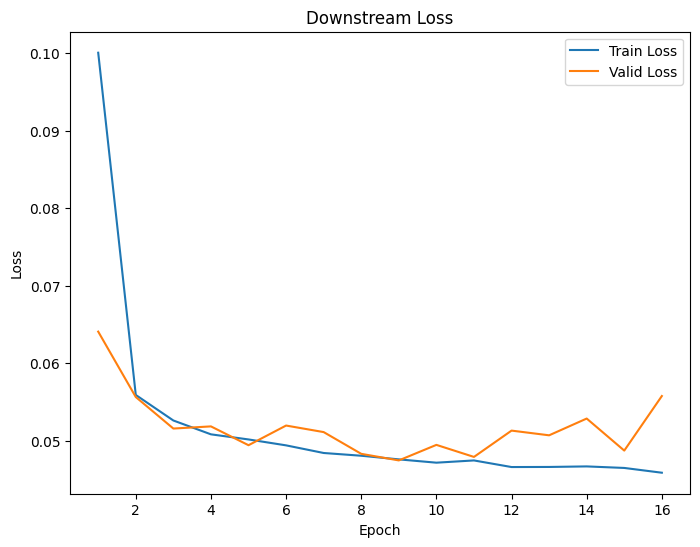

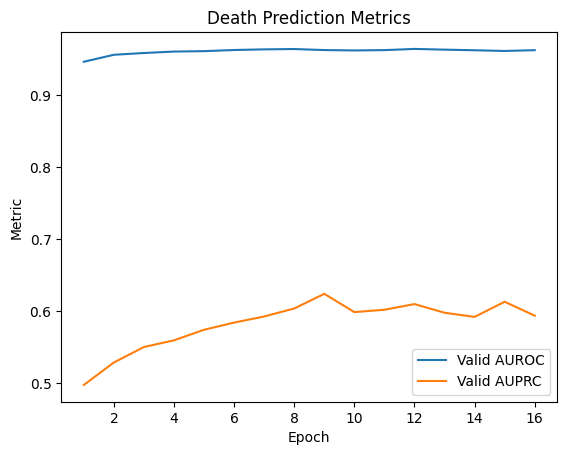

[STraTSExperiment] Downstream training finished.
[STraTSExperiment] Best downstream model saved at: ./models_pt\downstream_model_integ_cf.pt
[STraTSExperiment] Training loss saved to ./model_results\downstream_loss_integ_cf.csv


[Evaluating on dataset]:   0%|          | 0/2325 [00:00<?, ?it/s]

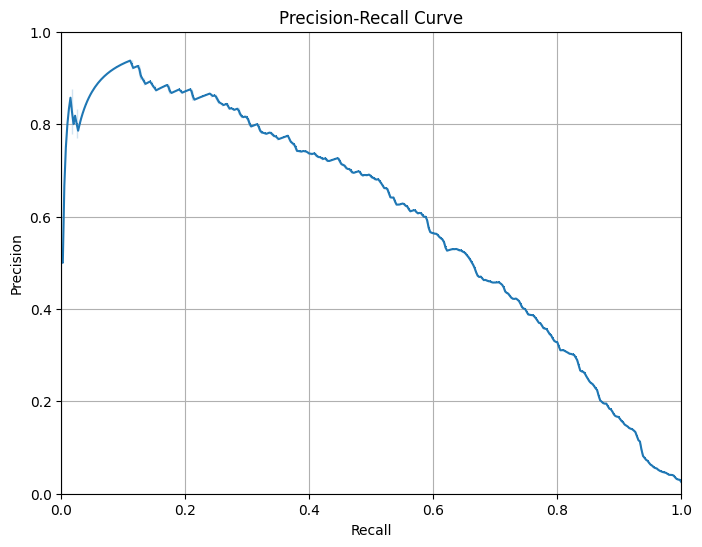

[STraTSExperiment] Test Metrics:
  AUROC: 0.9556
  AUPRC: 0.5950
  Precision: 0.6833
  Recall: 0.5062
  F1: 0.5816
  Accuracy: 0.9841
  Brier: 0.0127
  Precision@Recall_0.8: 0.3286


[Evaluating on dataset]:   0%|          | 0/6962 [00:00<?, ?it/s]

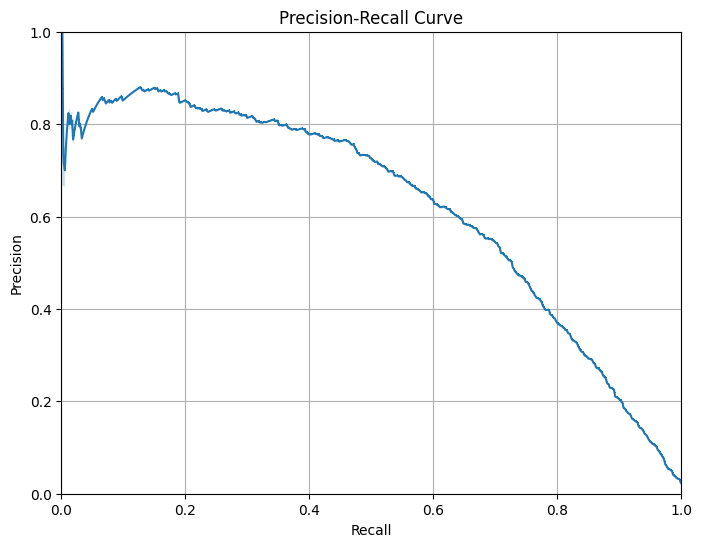

[Evaluating on dataset]:   0%|          | 0/2340 [00:00<?, ?it/s]

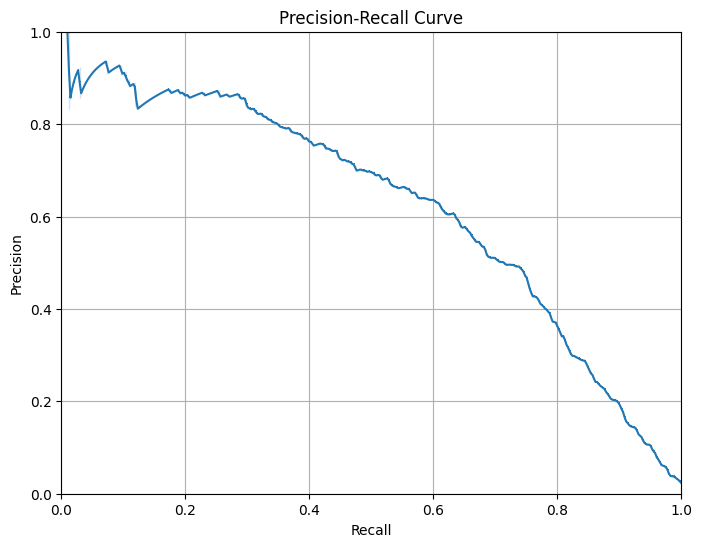

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_cf.csv


In [13]:
# 2) Downstream train
exp_0.train_downstream(epochs=1000,
                            freeze=False,
                            learning_rate=1e-4)

# 3) Evaluate
metrics_0 = exp_0.evaluate()

### Task 1

[STraTSExperiment] Initialized with version=integ_vital_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/2301 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


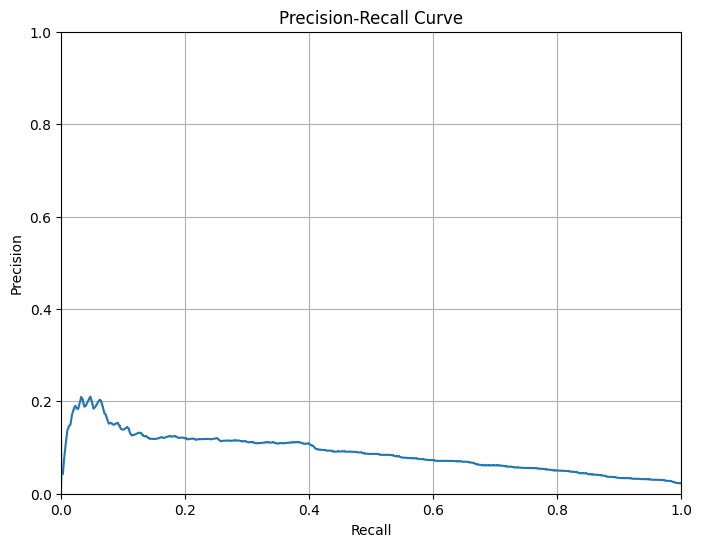

[STraTSExperiment] Test Metrics:
  AUROC: 0.8001
  AUPRC: 0.0895
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  Accuracy: 0.9780
  Brier: 0.0219
  Precision@Recall_0.8: 0.0503


[Evaluating on dataset]:   0%|          | 0/6900 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


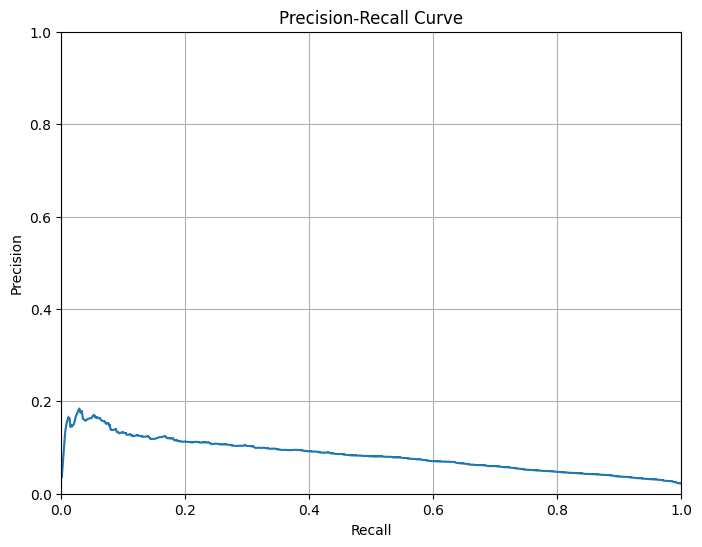

[Evaluating on dataset]:   0%|          | 0/2319 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


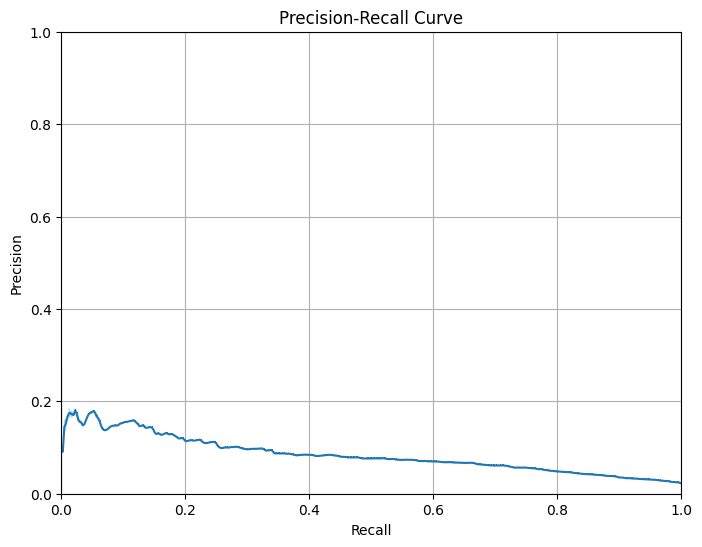

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_vital_cf.csv


In [14]:
# Fusion final_emb
exp_1 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_vital_loader,
    valid_loader=valid_vital_loader,
    test_loader=test_vital_loader,
    version='integ_vital_cf',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_1.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_1 = exp_1.evaluate()

### Task 2

[STraTSExperiment] Initialized with version=integ_lab_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/1084 [00:00<?, ?it/s]

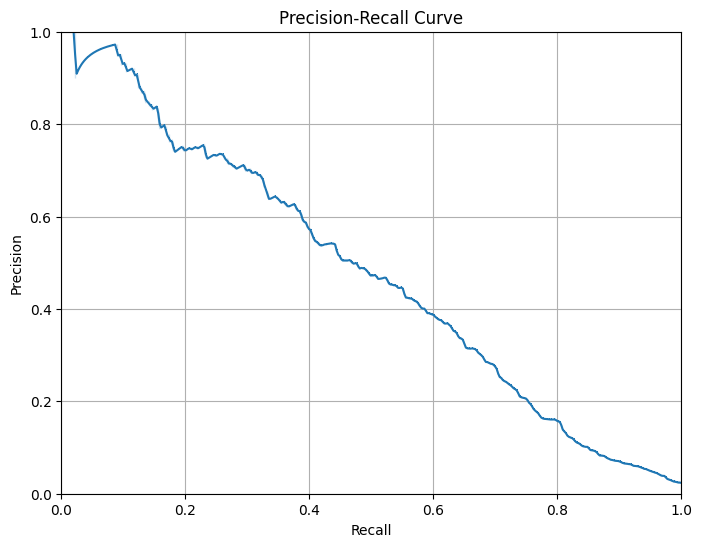

[STraTSExperiment] Test Metrics:
  AUROC: 0.9156
  AUPRC: 0.4806
  Precision: 0.7541
  Recall: 0.2283
  F1: 0.3505
  Accuracy: 0.9803
  Brier: 0.0163
  Precision@Recall_0.8: 0.1568


[Evaluating on dataset]:   0%|          | 0/3235 [00:00<?, ?it/s]

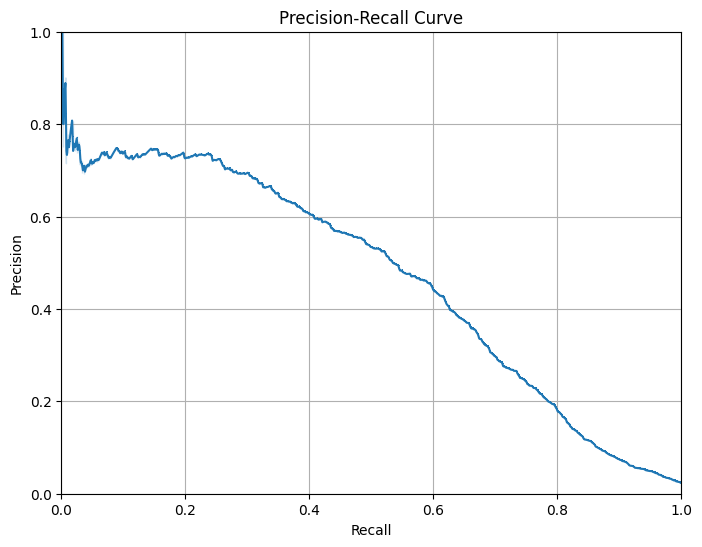

[Evaluating on dataset]:   0%|          | 0/1087 [00:00<?, ?it/s]

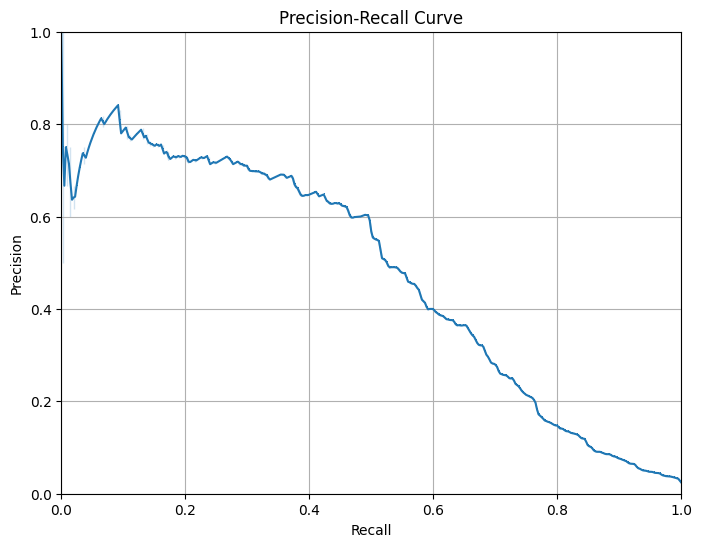

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_lab_cf.csv


In [15]:
# Lab
exp_2 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_lab_loader,
    valid_loader=valid_lab_loader,
    test_loader=test_lab_loader,
    version='integ_lab_cf',           # None이면 자동으로 날짜_2 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_2.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_2 = exp_2.evaluate()

### Task 3

[STraTSExperiment] Initialized with version=integ_treatment_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/841 [00:00<?, ?it/s]

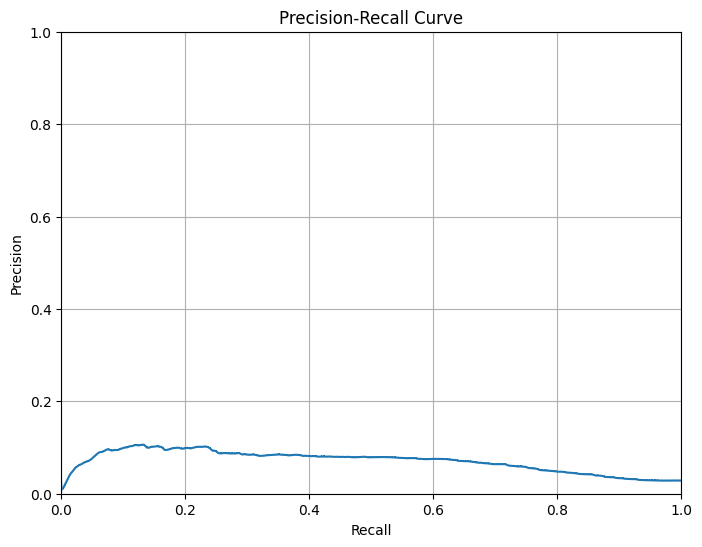

[STraTSExperiment] Test Metrics:
  AUROC: 0.7287
  AUPRC: 0.0709
  Precision: 0.0479
  Recall: 0.0182
  F1: 0.0264
  Accuracy: 0.9616
  Brier: 0.0364
  Precision@Recall_0.8: 0.0478


[Evaluating on dataset]:   0%|          | 0/2516 [00:00<?, ?it/s]

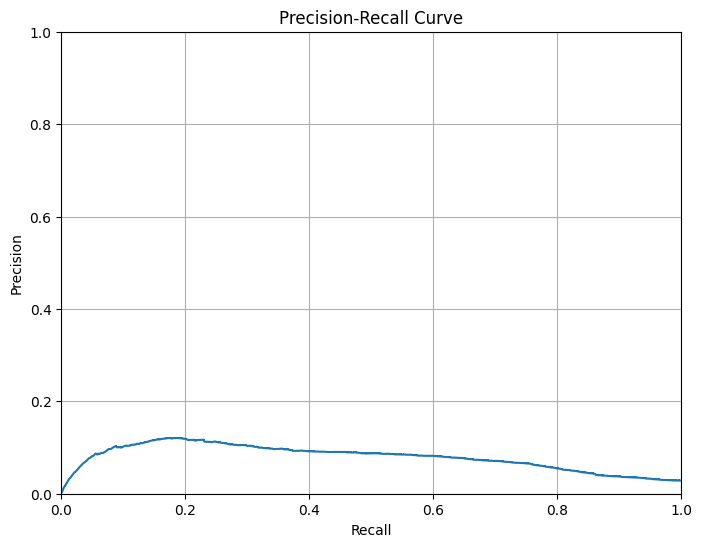

[Evaluating on dataset]:   0%|          | 0/846 [00:00<?, ?it/s]

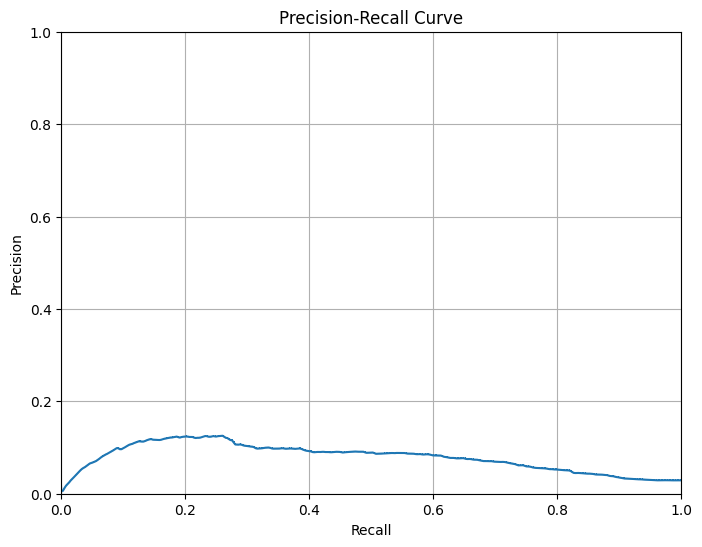

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_treatment_cf.csv


In [16]:
# treatment
exp_3 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_treatment_loader,
    valid_loader=valid_treatment_loader,
    test_loader=test_treatment_loader,
    version='integ_treatment_cf',           # None이면 자동으로 날짜_3 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_3.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_3 = exp_3.evaluate()

### Task 4

[STraTSExperiment] Initialized with version=integ_mimic_vital_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/818 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


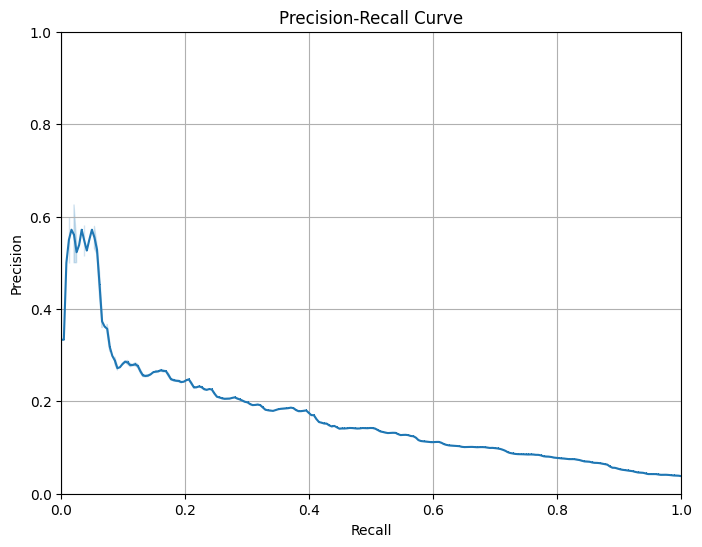

[STraTSExperiment] Test Metrics:
  AUROC: 0.7853
  AUPRC: 0.1709
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  Accuracy: 0.9629
  Brier: 0.0370
  Precision@Recall_0.8: 0.0779


[Evaluating on dataset]:   0%|          | 0/2443 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


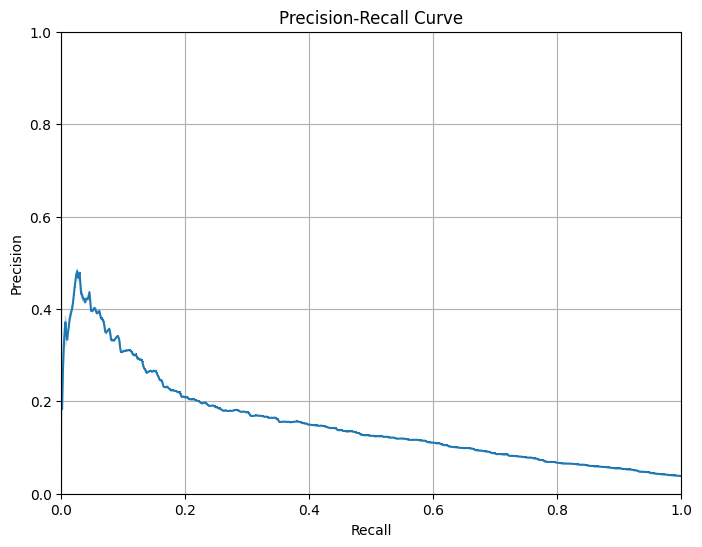

[Evaluating on dataset]:   0%|          | 0/836 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


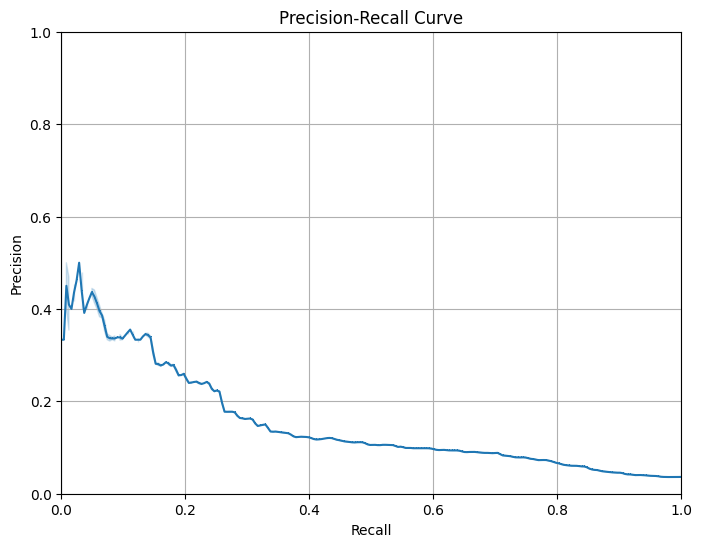

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_mimic_vital_cf.csv


In [17]:
# Fusion final_emb
exp_4 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_vital_loader_mimic,
    valid_loader=valid_vital_loader_mimic,
    test_loader=test_vital_loader_mimic,
    version='integ_mimic_vital_cf',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_4.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_4 = exp_4.evaluate()

### Task 5

[STraTSExperiment] Initialized with version=integ_mimic_lab_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/399 [00:00<?, ?it/s]

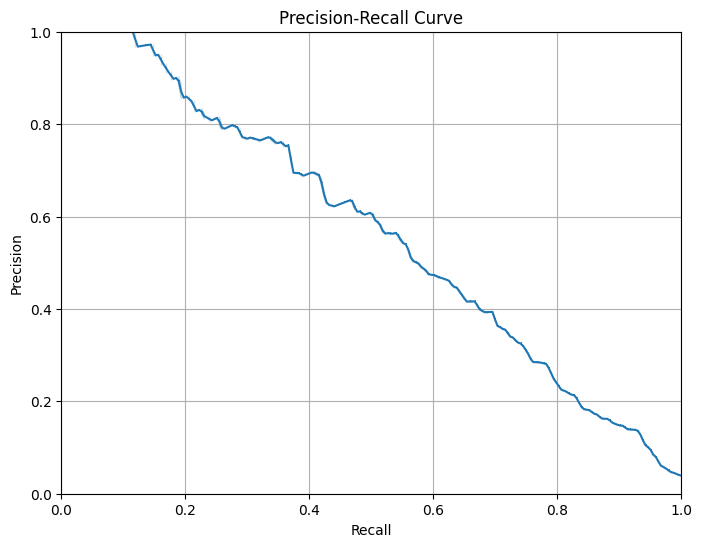

[STraTSExperiment] Test Metrics:
  AUROC: 0.9249
  AUPRC: 0.5698
  Precision: 0.8133
  Recall: 0.2510
  F1: 0.3836
  Accuracy: 0.9692
  Brier: 0.0251
  Precision@Recall_0.8: 0.2404


[Evaluating on dataset]:   0%|          | 0/1182 [00:00<?, ?it/s]

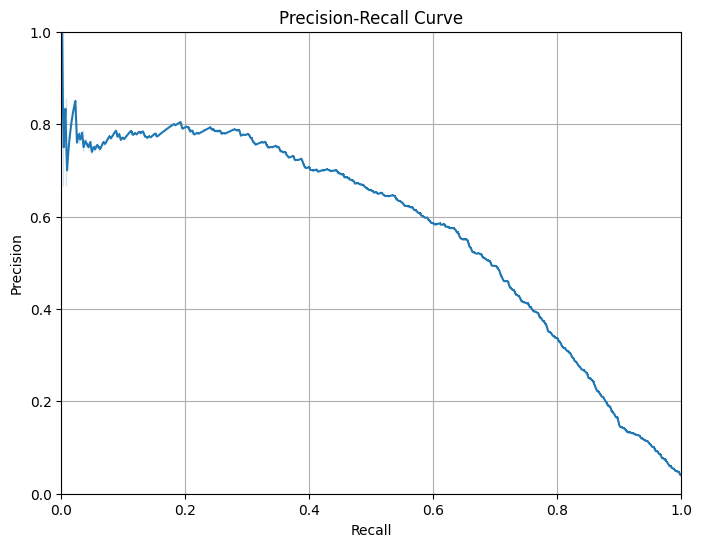

[Evaluating on dataset]:   0%|          | 0/403 [00:00<?, ?it/s]

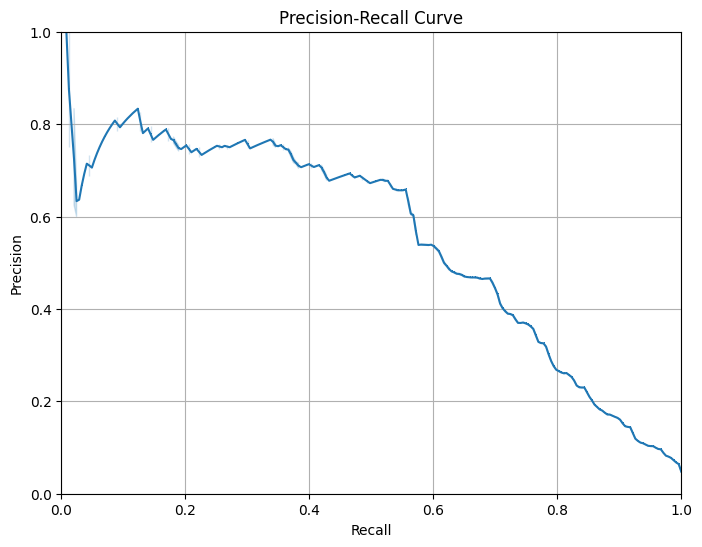

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_mimic_lab_cf.csv


In [18]:
# Lab
exp_5 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_lab_loader_mimic,
    valid_loader=valid_lab_loader_mimic,
    test_loader=test_lab_loader_mimic,
    version='integ_mimic_lab_cf',           # None이면 자동으로 날짜_5 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_5.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_5 = exp_5.evaluate()

### Task 6

[STraTSExperiment] Initialized with version=integ_mimic_treatment_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/384 [00:00<?, ?it/s]

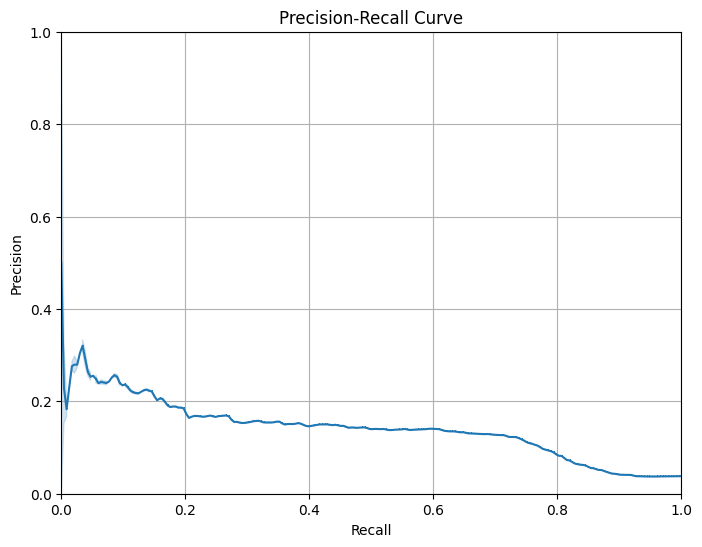

[STraTSExperiment] Test Metrics:
  AUROC: 0.7695
  AUPRC: 0.1435
  Precision: 0.2857
  Recall: 0.0258
  F1: 0.0472
  Accuracy: 0.9606
  Brier: 0.0369
  Precision@Recall_0.8: 0.0826


[Evaluating on dataset]:   0%|          | 0/1150 [00:00<?, ?it/s]

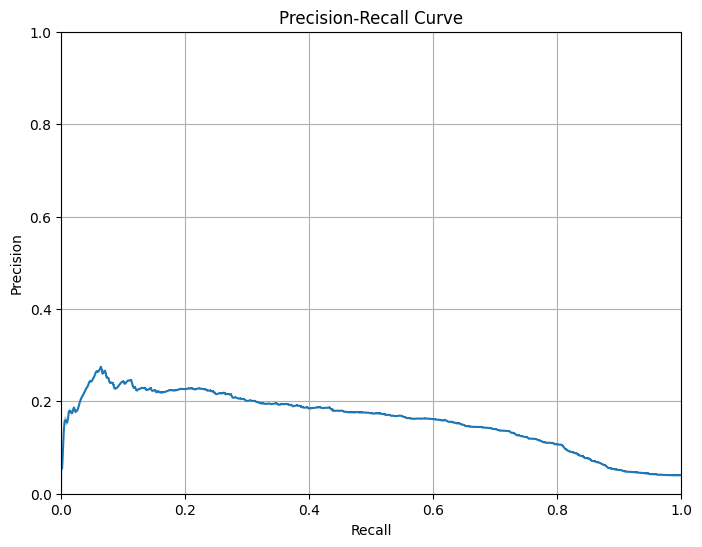

[Evaluating on dataset]:   0%|          | 0/393 [00:00<?, ?it/s]

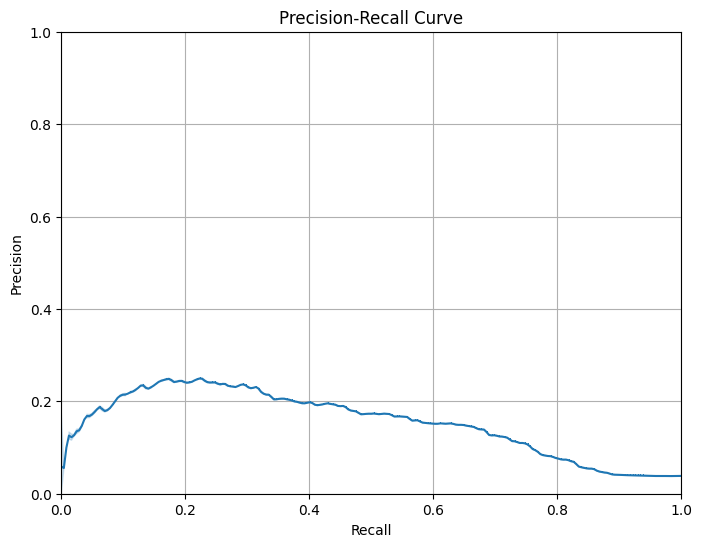

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_mimic_treatment_cf.csv


In [19]:
# treatment
exp_6 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_treatment_loader_mimic,
    valid_loader=valid_treatment_loader_mimic,
    test_loader=test_treatment_loader_mimic,
    version='integ_mimic_treatment_cf',           # None이면 자동으로 날짜_6 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_6.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_6 = exp_6.evaluate()

### Task 7

[STraTSExperiment] Initialized with version=integ_eicu_vital_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/1483 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


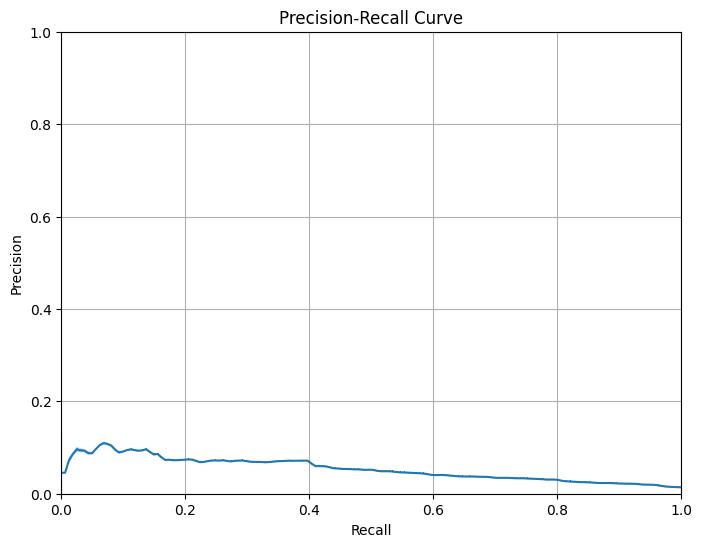

[STraTSExperiment] Test Metrics:
  AUROC: 0.7892
  AUPRC: 0.0543
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  Accuracy: 0.9864
  Brier: 0.0135
  Precision@Recall_0.8: 0.0308


[Evaluating on dataset]:   0%|          | 0/4458 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


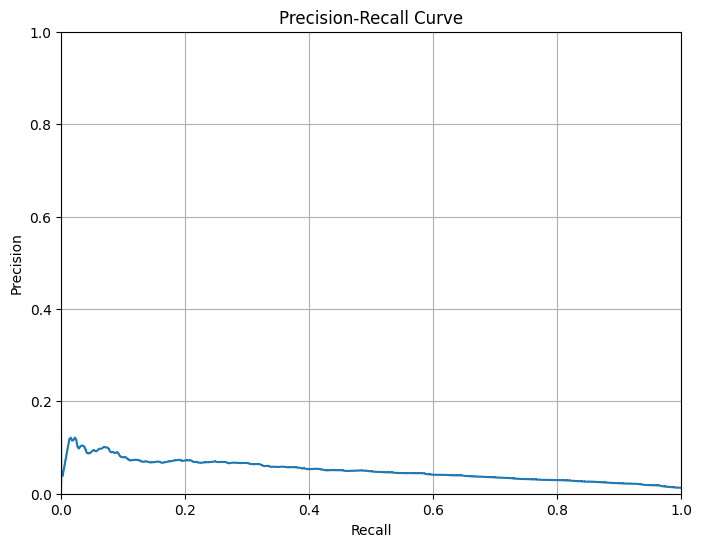

[Evaluating on dataset]:   0%|          | 0/1483 [00:00<?, ?it/s]

c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


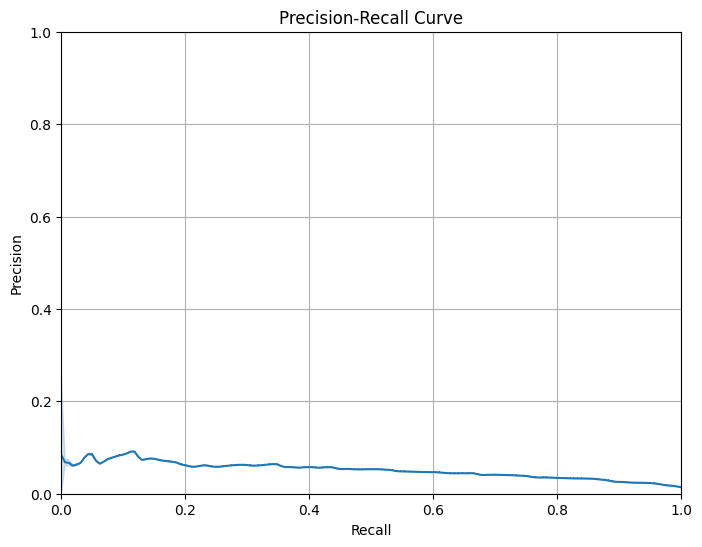

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_eicu_vital_cf.csv


In [20]:
# Fusion final_emb
exp_7 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_vital_loader_eicu,
    valid_loader=valid_vital_loader_eicu,
    test_loader=test_vital_loader_eicu,
    version='integ_eicu_vital_cf',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_7.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_7 = exp_7.evaluate()

### Task 8

[STraTSExperiment] Initialized with version=integ_eicu_lab_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/686 [00:00<?, ?it/s]

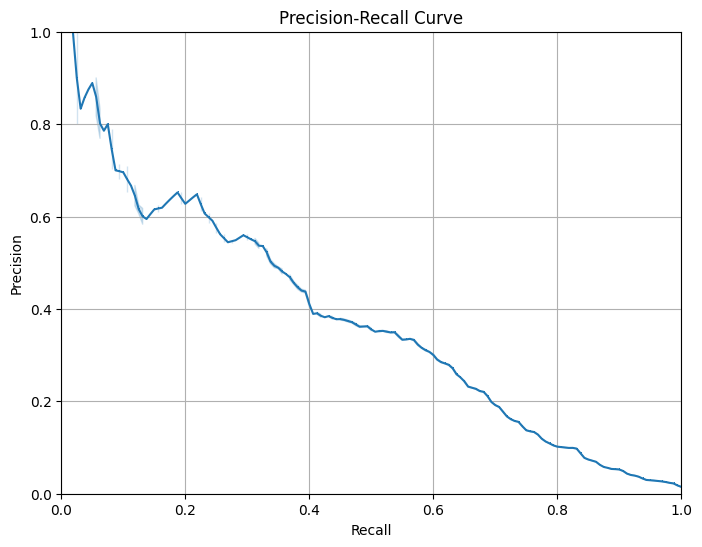

[STraTSExperiment] Test Metrics:
  AUROC: 0.9223
  AUPRC: 0.3792
  Precision: 0.6596
  Recall: 0.1938
  F1: 0.2995
  Accuracy: 0.9868
  Brier: 0.0111
  Precision@Recall_0.8: 0.1030


[Evaluating on dataset]:   0%|          | 0/2054 [00:00<?, ?it/s]

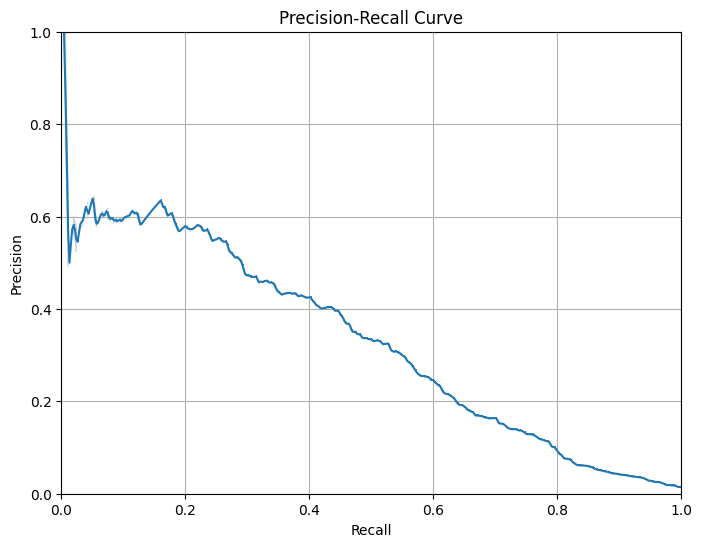

[Evaluating on dataset]:   0%|          | 0/684 [00:00<?, ?it/s]

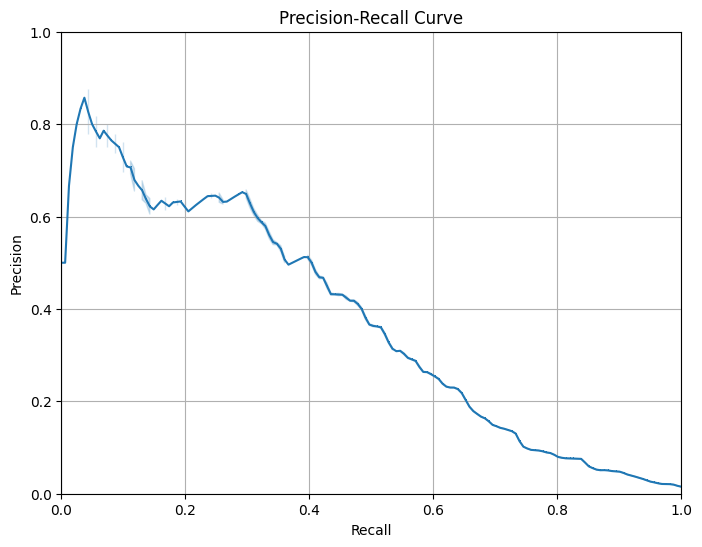

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_eicu_lab_cf.csv


In [21]:
# Lab
exp_8 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_lab_loader_eicu,
    valid_loader=valid_lab_loader_eicu,
    test_loader=test_lab_loader_eicu,
    version='integ_eicu_lab_cf',           # None이면 자동으로 날짜_8 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_8.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_8 = exp_8.evaluate()

### Task 9

[STraTSExperiment] Initialized with version=integ_eicu_treatment_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/457 [00:00<?, ?it/s]

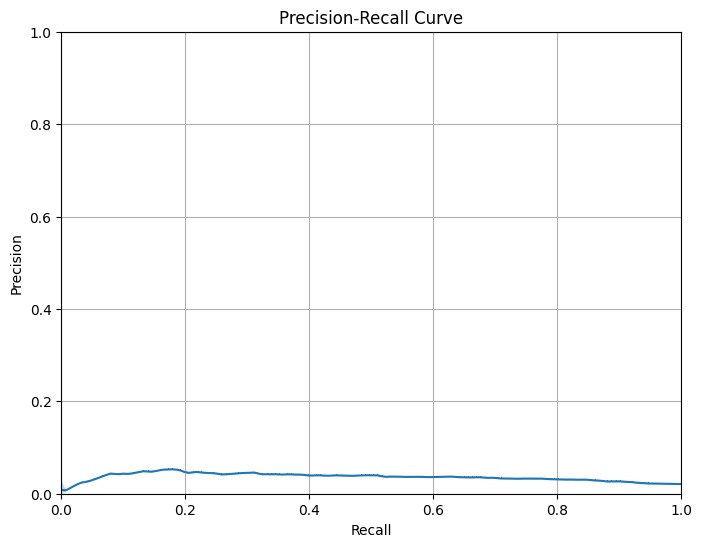

[STraTSExperiment] Test Metrics:
  AUROC: 0.6788
  AUPRC: 0.0366
  Precision: 0.0080
  Recall: 0.0066
  F1: 0.0072
  Accuracy: 0.9625
  Brier: 0.0360
  Precision@Recall_0.8: 0.0312


[Evaluating on dataset]:   0%|          | 0/1366 [00:00<?, ?it/s]

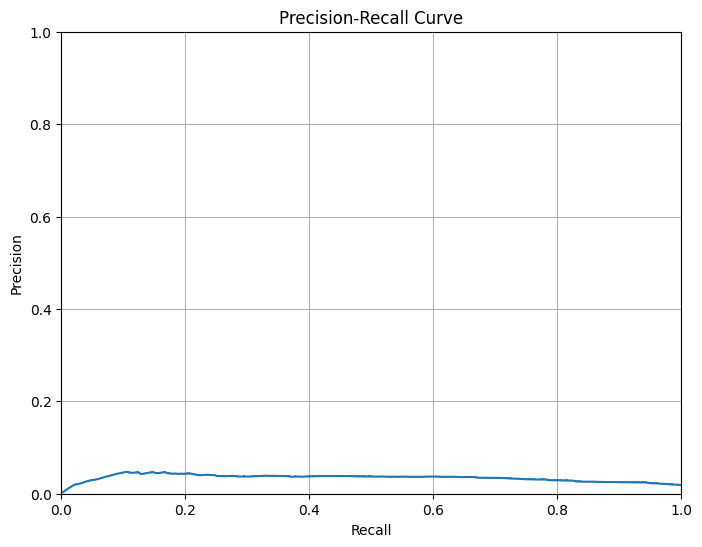

[Evaluating on dataset]:   0%|          | 0/454 [00:00<?, ?it/s]

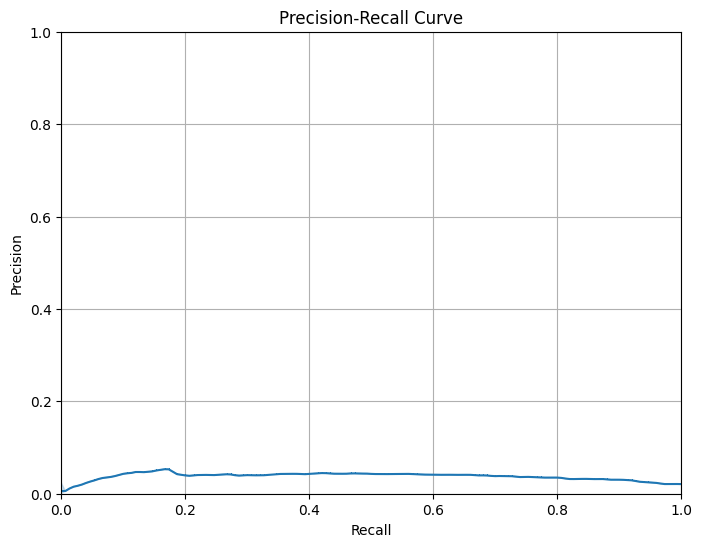

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_eicu_treatment_cf.csv


In [22]:
# treatment
exp_9 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_treatment_loader_eicu,
    valid_loader=valid_treatment_loader_eicu,
    test_loader=test_treatment_loader_eicu,
    version='integ_eicu_treatment_cf',           # None이면 자동으로 날짜_9 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_9.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_9 = exp_9.evaluate()

### Task 10

[STraTSExperiment] Initialized with version=integ_eicu_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/1493 [00:00<?, ?it/s]

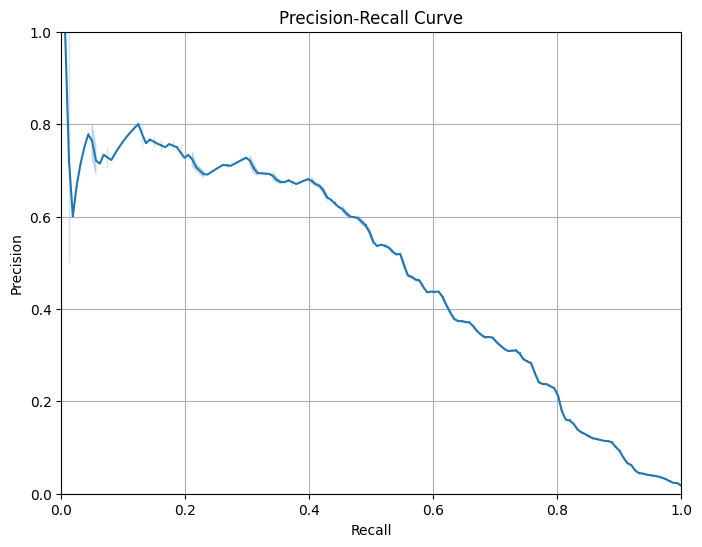

[STraTSExperiment] Test Metrics:
  AUROC: 0.9530
  AUPRC: 0.4890
  Precision: 0.6048
  Recall: 0.4658
  F1: 0.5263
  Accuracy: 0.9887
  Brier: 0.0091
  Precision@Recall_0.8: 0.2287


[Evaluating on dataset]:   0%|          | 0/4484 [00:00<?, ?it/s]

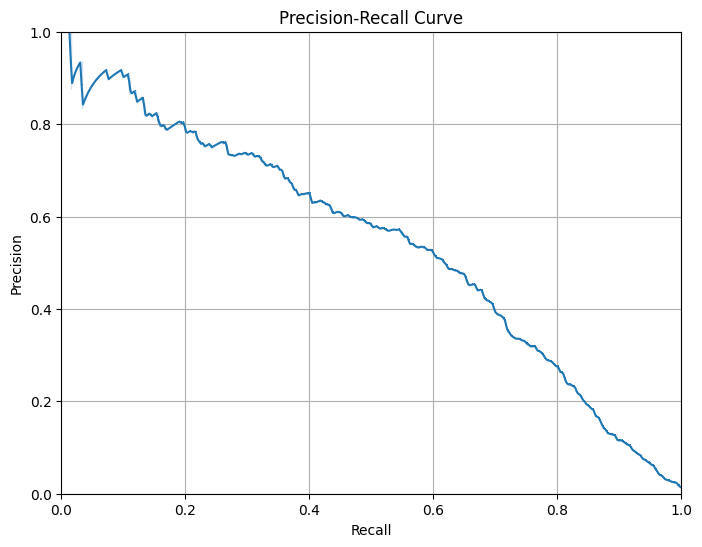

[Evaluating on dataset]:   0%|          | 0/1492 [00:00<?, ?it/s]

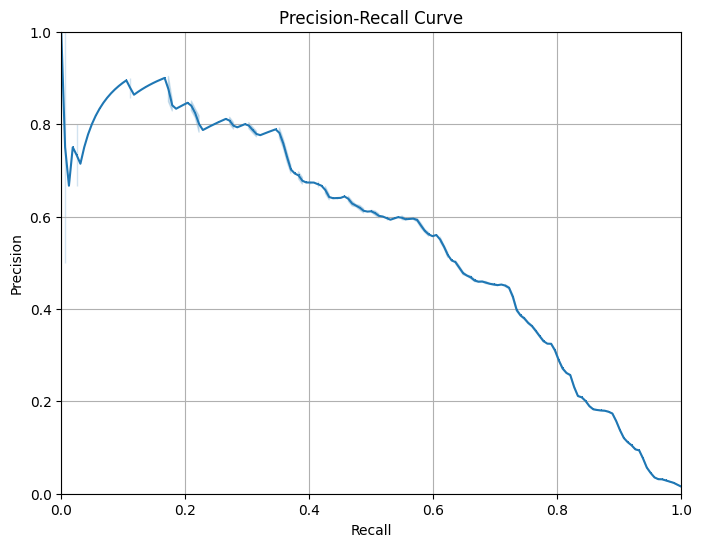

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_eicu_cf.csv


In [23]:
# treatment
exp_10 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader_eicu,
    valid_loader=valid_loader_eicu,
    test_loader=test_loader_eicu,
    version='integ_eicu_cf',           # None이면 자동으로 날짜_10 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_10.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_10 = exp_10.evaluate()

### Task 11

[STraTSExperiment] Initialized with version=integ_mimic_cf, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_integ_cf.pt


[Evaluating on dataset]:   0%|          | 0/832 [00:00<?, ?it/s]

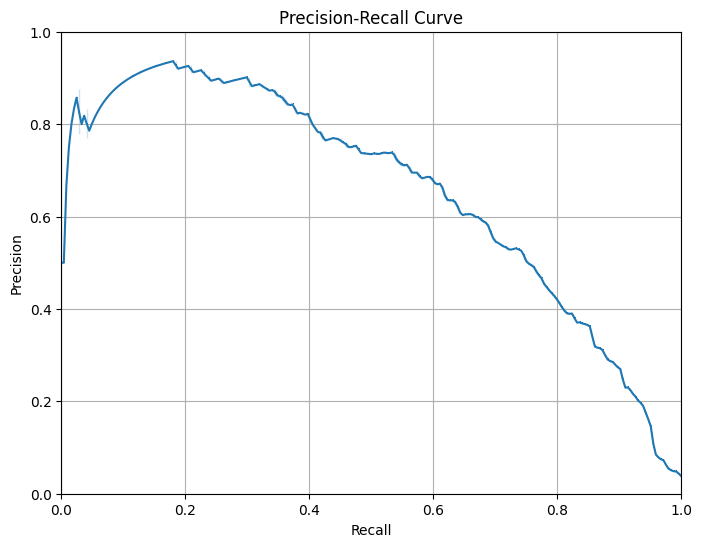

[STraTSExperiment] Test Metrics:
  AUROC: 0.9523
  AUPRC: 0.6578
  Precision: 0.7386
  Recall: 0.5328
  F1: 0.6190
  Accuracy: 0.9760
  Brier: 0.0192
  Precision@Recall_0.8: 0.4197


[Evaluating on dataset]:   0%|          | 0/2479 [00:00<?, ?it/s]

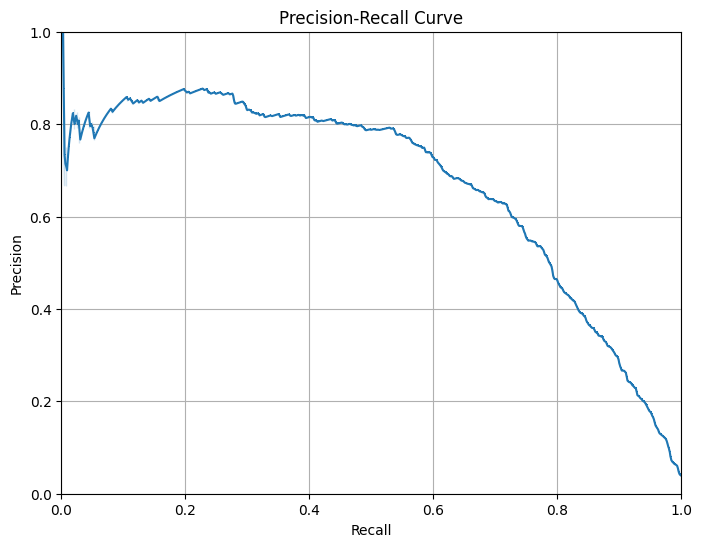

[Evaluating on dataset]:   0%|          | 0/848 [00:00<?, ?it/s]

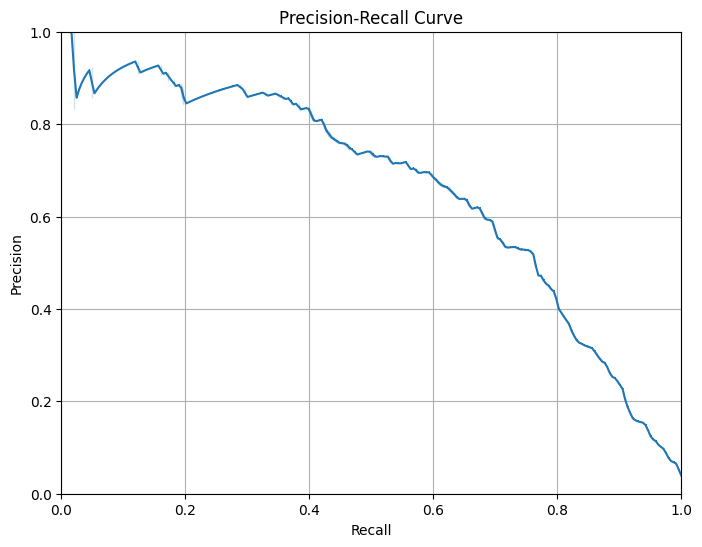

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_integ_mimic_cf.csv


In [24]:
# mimic
exp_11 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader_mimic,
    valid_loader=valid_loader_mimic,
    test_loader=test_loader_mimic,
    version='integ_mimic_cf', 
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_11.load_downstream_model('./models_pt/downstream_model_integ_cf.pt')

metrics_11 = exp_11.evaluate()